# Recognize Handwritten Digits Using a Deep Neural Network (TensorFlow)

Misma red y mismos pasos que `solution.ipynb`, pero con TensorFlow/Keras en lugar de PyTorch.

In [1]:
# Task 1: Import Modules
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from time import time
from tensorflow import keras

In [2]:
# Task 2: Create a Transformation
# Equivale a ToTensor() + Normalize((0.5,), (0.5,)): pixeles 0-255 -> 0-1 -> -1 a 1
def transformation(images):
    images = images.astype(np.float32) / 255.0
    return (images - 0.5) / 0.5

In [3]:
# Task 3: Download and Load Datasets
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train, x_test = transformation(x_train), transformation(x_test)

train_data = tf.data.Dataset.from_tensor_slices((x_train, y_train)).shuffle(60000).batch(64)
test_data = tf.data.Dataset.from_tensor_slices((x_test, y_test)).batch(64)

print(len(x_train), len(x_test))

       0/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

   49152/11490434 ━━━━━━━━━━━━━━━━━━━━ 11s 1us/step

  147456/11490434 ━━━━━━━━━━━━━━━━━━━━ 7s 1us/step 

  368640/11490434 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step

 1130496/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

...

 7577600/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

 9347072/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

11132928/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


60000 10000


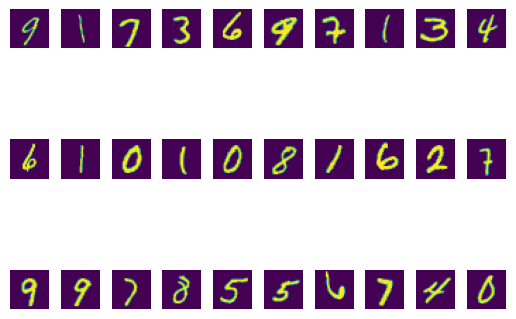

In [4]:
# Task 4: Visualize Images
images, labels = next(iter(train_data))
for i in range(1, 31):
    plt.subplot(3, 10, i)
    plt.subplots_adjust(wspace=0.3)
    plt.imshow(images[i].numpy().squeeze())
    plt.axis('off')

In [5]:
# Task 5: Calculate Size of Layers
input_layer = 28 * 28
hidden_layer1 = 128
hidden_layer2 = 64
output_layer = 10

In [6]:
# Task 6: Build a Model
# Sin softmax al final: la red devuelve logits y la pérdida aplica softmax internamente
model = keras.Sequential([
    keras.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(hidden_layer1, activation='relu'),
    keras.layers.Dense(hidden_layer2, activation='relu'),
    keras.layers.Dense(output_layer),
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Task 7: Calculate Cross-Entropy Loss
cse = keras.losses.SparseCategoricalCrossentropy(from_logits=True)
loss = cse(labels, model(images))
print(float(loss))

2.5980963706970215


In [8]:
# Task 8: Obtain the Stochastic Gradient Descent Optimizer
optimizer = keras.optimizers.SGD(learning_rate=0.003, momentum=0.9)

In [9]:
# Task 9: Train the Model
# GradientTape hace lo que en PyTorch son zero_grad(), backward() y step()
@tf.function
def train_step(images, labels):
    with tf.GradientTape() as tape:
        loss = cse(labels, model(images, training=True))
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    return loss

epochs = 15
start = time()
for epoch in range(epochs):
    total_loss = 0.0
    batches = 0
    for images, labels in train_data:
        total_loss += float(train_step(images, labels))
        batches += 1
    print(f'Epoch {epoch + 1}/{epochs} - loss: {total_loss / batches:.4f}')
print(f'\nTiempo de entrenamiento: {(time() - start) / 60:.2f} min')

Epoch 1/15 - loss: 0.4425


Epoch 2/15 - loss: 0.2234


Epoch 3/15 - loss: 0.1708


Epoch 4/15 - loss: 0.1378


Epoch 5/15 - loss: 0.1193


...

Epoch 11/15 - loss: 0.0614


Epoch 12/15 - loss: 0.0562


Epoch 13/15 - loss: 0.0514


Epoch 14/15 - loss: 0.0474


Epoch 15/15 - loss: 0.0432

Tiempo de entrenamiento: 0.09 min


In [10]:
# Task 10: Get the Predicted Label
def get_predicted_label(image):
    logits = model(image[np.newaxis, ...], training=False)
    probabilities = tf.nn.softmax(logits)[0].numpy()
    return int(np.argmax(probabilities)), probabilities

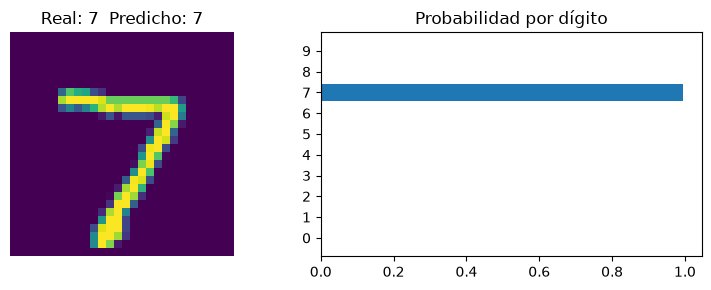

In [11]:
# Task 10: Test the Prediction Method
images, labels = next(iter(test_data))
predicted, probabilities = get_predicted_label(images[0])

plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.imshow(images[0].numpy().squeeze())
plt.title(f'Real: {int(labels[0])}  Predicho: {predicted}')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.barh(range(10), probabilities)
plt.yticks(range(10))
plt.title('Probabilidad por dígito')
plt.tight_layout()

In [12]:
# Task 11: Test the Model
correct = 0
total = 0
for images, labels in test_data:
    predictions = tf.argmax(model(images, training=False), axis=1)
    correct += int(tf.reduce_sum(tf.cast(predictions == tf.cast(labels, tf.int64), tf.int32)))
    total += len(labels)
print(f'Imágenes de prueba: {total}')
print(f'Precisión del modelo: {correct / total:.2%}')

Imágenes de prueba: 10000
Precisión del modelo: 97.37%
